In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Impor library MLlib
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler
)
from pyspark.ml.classification import (
     RandomForestClassifier, GBTClassifier
)

# Hentikan SparkSession jika ada yang aktif
try:
    spark.stop()
except:
    pass

# Buat SparkSession baru
spark = SparkSession.builder \
    .appName("ChurnModeling") \
    .config("spark.driver.memory", "12g") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("SparkSession dan library MLlib siap.")

SparkSession dan library MLlib siap.


In [3]:
data_path = "data_final/master_feature_table_final.parquet"
df = spark.read.parquet(data_path)
df.printSchema()

root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- age_group: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- total_plan_days: long (nullable = true)
 |-- total_amount_paid: double (nullable = true)
 |-- avg_amount_paid: double (nullable = true)
 |-- count_auto_renew: long (nullable = true)
 |-- count_cancel: long (nullable = true)
 |-- most_frequent_payment_method: integer (nullable = true)
 |-- days_since_last_activity: integer (nullable = true)
 |-- total_secs_last_1month: double (nullable = true)
 |-- active_days_last_1month: long (nullable = true)
 |-- total_secs_last_3month: double (nullable = true)
 |-- active_days_last_3month: long (nullable = true)
 |-- percent_complete_last_1month: double (nullable = true)
 |-- lifetime_active_days: long (nullable = true)



In [4]:
# --- 2. PREPARE DATA (pilih cols) ---
    
cols_to_keep = [
    "msno",
    "is_churn",
    # "city", # feature importance rendah
    # "age_group", # feature importance rendah
    # "registered_via", # feature importance rendah
    "total_transactions",  
    # "total_plan_days",
    # "total_amount_paid",
    "avg_amount_paid", # medium effect size
    "count_auto_renew", # effect size > 5 huge
    "count_cancel",
    "most_frequent_payment_method", # medium effect size
    "days_since_last_activity", # medium effect size
    "total_secs_last_1month",
    "active_days_last_1month",
    # "total_secs_last_3month",
    # "active_days_last_3month",
    # "percent_complete_last_1month", # feature importance rendah
    # "lifetime_active_days",
    # "lifetime_unq_songs"
]

# Ambil cmn kolom yang diminta dari master table
df_selected = df.select(*cols_to_keep)

# --- ubah age_group jadi numerik ---

# Buat DataFrame baru dengan kolom age_group yang sudah diubah menjadi numerik
# df_selected = df_selected.withColumn(
#     "age_group_num",
#     F.when(F.col("age_group").isNull(), 0) # Kasus NULL diubah menjadi 0
#     .when(F.col("age_group") == "Unknown", 0) # Kasus 'Unknown' diubah menjadi 0
#     .when(F.col("age_group").contains("0-17"), 1) # 0-17 (Remaja) = 1
#     .when(F.col("age_group").contains("18-25"), 2) # 18-25 (Muda) = 2
#     .when(F.col("age_group").contains("26-35"), 3) # 26-35 (Dewasa) = 3
#     .when(F.col("age_group").contains("36-45"), 4) # 36-45 (Paruh Baya) = 4
#     .when(F.col("age_group").contains("46-90"), 5) # 46-90 (Senior) = 5
# )

# df_selected = df_selected.drop("age_group")
print("Skema Final Data Latih:")
df_selected.printSchema()
print(df_selected.count())

Skema Final Data Latih:
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- avg_amount_paid: double (nullable = true)
 |-- count_auto_renew: long (nullable = true)
 |-- count_cancel: long (nullable = true)
 |-- most_frequent_payment_method: integer (nullable = true)
 |-- days_since_last_activity: integer (nullable = true)
 |-- total_secs_last_1month: double (nullable = true)
 |-- active_days_last_1month: long (nullable = true)

1082190


### Tanpa Oversampling/Undersampling

In [ ]:
# # # --- 3. SPLIT ---
# print("\nMembagi Data Latih (80%) & Uji (20%)...")
# train_data, test_data = df_selected.randomSplit([0.8, 0.2], seed=42)

# print("Melakukan Oversampling...")
# print(f"data_train:{train_data.count()}")
# print(f"data_test: {test_data.count()}")


Membagi Data Latih (80%) & Uji (20%)...
Melakukan Oversampling...
data_train:865689
data_test: 216501


### Oversampling

In [5]:
# --- 3. SPLIT & OVERSAMPLING (15%) ---
label_col = "is_churn"

print("Membagi Data Latih (80%) & Uji (20%)...")
train_data, test_data = df_selected.randomSplit([0.8, 0.2], seed=42)

print("Melakukan Oversampling...")
print(f"Jumlah data train: {train_data.count()}")
print(f"Jumlah data test: {test_data.count()}")


major_df = train_data.filter(F.col(label_col) == 0)
minor_df = train_data.filter(F.col(label_col) == 1)


count_major = major_df.count()
count_minor = minor_df.count()

# Tentukan rasio tambahan (13%)
ratio_tambahan = (0.13 * train_data.count() - count_minor)/count_minor
print(f"ratio tambahan: {ratio_tambahan} dari data minoritas")

# Ambil sampel tambahan (Hanya mengambil 13% dari keseluruhan data)
df_minority_extra = minor_df.sample(
    withReplacement=True, 
    fraction=ratio_tambahan, 
    seed=42
)
train_data_balanced = major_df.unionAll(df_minority_extra).unionAll(minor_df)

minor_union = train_data_balanced.filter(F.col(label_col) == 1)

print(f"\nData Latih Awal: {train_data.count()}")
print(f"Data Latih Baru: {train_data_balanced.count()}, bertambah {train_data_balanced.count() - train_data.count()}")

print(f"\nJumlah data major lama (not churn) {count_major}")
print(f"Jumlah data minor lama (churn) {count_minor}")
print(f"Jumlah data minor baru (churn): {minor_union.count()}, bertambah sebanyak {minor_union.count()-count_minor} data")


print(f"Persentase Data Mayoritas Baru: {count_major/train_data_balanced.count()*100:.2f}%")
print(f"Persentase Data Minoritas Baru: {minor_union.count()/train_data_balanced.count()*100:.2f}%")

Membagi Data Latih (80%) & Uji (20%)...
Melakukan Oversampling...
Jumlah data train: 865689
Jumlah data test: 216501
ratio tambahan: 0.4218158732565192 dari data minoritas

Data Latih Awal: 865689
Data Latih Baru: 898886, bertambah 33197

Jumlah data major lama (not churn) 786537
Jumlah data minor lama (churn) 79152
Jumlah data minor baru (churn): 112349, bertambah sebanyak 33197 data
Persentase Data Mayoritas Baru: 87.50%
Persentase Data Minoritas Baru: 12.50%


### Undersampling

In [ ]:
# # --- 3. SPLIT & Undersampling (15%) ---
# label_col = "is_churn"

# print("\nMembagi Data Latih (80%) & Uji (20%)...")
# train_data, test_data = df_selected.randomSplit([0.8, 0.2], seed=42)

# print("Melakukan Undersampling...")
# print(f"Jumlah data train: {train_data.count()}")
# print(f"Jumlah data test: {test_data.count()}")

# major_df = train_data.filter(F.col(label_col) == 0)
# minor_df = train_data.filter(F.col(label_col) == 1)


# count_major = major_df.count()
# count_minor = minor_df.count()

# print(f"Jumlah Awal Mayoritas (0): {count_major:,}")
# print(f"Jumlah Awal Minoritas (1): {count_minor:,}")

# # Tentukan rasio kurangin (15%)
# ratio_ambil_major = 1-(0.15 * train_data.count() / count_major)

# # Ambil sampel kurangin (Kurangi 15% dr keseluruhan)
# df_majority_sample = major_df.sample(
#     withReplacement=True, 
#     fraction=ratio_ambil_major, 
#     seed=42
# )

# # Gabungkan: Mayoritas Asli + Minoritas Asli + Minoritas Ekstra
# train_data_balanced = minor_df.union(df_majority_sample)

# minor_union = train_data_balanced.filter(F.col(label_col) == 1)
# print(f"count major new: {df_majority_sample.count()}, berkurang sebanyak {count_major-df_majority_sample.count()} data")

# print(f"\nData Latih Awal: {train_data.count()}")
# print(f"Data Latih Baru: {train_data_balanced.count()}, berkurang {train_data.count() - train_data_balanced.count()}")

# print(f"\nJumlah data major lama (not churn): {count_major}")
# print(f"Jumlah data major baru (not churn): {df_majority_sample.count()}, berkurang sebanyak {count_major-df_majority_sample.count()} data")
# print(f"Jumlah data minor lama (churn): {minor_union.count()}")

# print(f"Persentase Data Mayoritas: {df_majority_sample.count()/train_data_balanced.count()*100:.2f}%")
# print(f"Persentase Data Minoritas: {minor_union.count()/train_data_balanced.count()*100:.2f}%")


Membagi Data Latih (80%) & Uji (20%)...
Melakukan Undersampling...
Jumlah data train: 865689
Jumlah data test: 216501
Jumlah Awal Mayoritas (0): 786,537
Jumlah Awal Minoritas (1): 79,152
count major new: 655227, berkurang sebanyak 131310 data

Data Latih Awal: 865689
Data Latih Baru: 734379, berkurang 131310

Jumlah data major lama (not churn): 786537
Jumlah data major baru (not churn): 655227, berkurang sebanyak 131310 data
Jumlah data minor lama (churn): 79152
Persentase Data Mayoritas: 89.22%
Persentase Data Minoritas: 10.78%


### Model Pipeline

In [6]:
# --- 4. PIPELINE STAGES ---
label_col = "is_churn"
numerical_cols = [
    col for col in df_selected.columns 
    if col not in [label_col, "msno"] 
]


stages = []

assembler_num = VectorAssembler(
    inputCols=numerical_cols, 
    outputCol="features"
)
stages += [assembler_num]

### Modeling

In [7]:
# --- 5. TRAINING ---

# GBT
print("\n--- Melatih GBT ---")
gbt = GBTClassifier(labelCol=label_col, featuresCol="features", seed=42)
pipeline_gbt = Pipeline(stages=stages + [gbt])
model_gbt = pipeline_gbt.fit(train_data_balanced)
preds_gbt = model_gbt.transform(test_data)


# Random Forest
# print("--- Melatih Random Forest ---")
# rf = RandomForestClassifier(labelCol=label_col, featuresCol="features", seed=42)
# pipeline_rf = Pipeline(stages=stages + [rf])
# model_rf = pipeline_rf.fit(train_data)
# preds_rf = model_rf.transform(test_data)


--- Melatih GBT ---


In [ ]:
# GBT Tuned
print("\n--- Melatih GBT Tuned---")
gbt_tuned = GBTClassifier(
    labelCol=label_col, 
    featuresCol="features", 
    seed=42,
    maxDepth=10, 
    maxIter=50   
)
pipeline_gbt_tuned = Pipeline(stages=stages + [gbt_tuned])
model_gbt_tuned = pipeline_gbt_tuned.fit(train_data_balanced)
preds_gbt_tuned = model_gbt_tuned.transform(test_data)


--- Melatih GBT Tuned---


### Model Evaluation

In [8]:
# --- 6. EVALUATION ---

from pyspark.sql.functions import col

def evaluate_model_detailed(predictions, model_name):
    """
    Menghitung Confusion Matrix, Accuracy, dan 
    Precision/Recall per kelas (Churn & Not Churn)
    menggunakan DataFrame API yang stabil.
    """
    print(f"\n{'='*40}")
    print(f"DETAIL EVALUASI: {model_name}")
    print(f"{'='*40}")
    
    predictions.cache()
    
    # 1. Hitung Komponen Confusion Matrix
    # TP: Prediksi Churn, Aslinya Churn
    tp = predictions.filter((col("prediction") == 1.0) & (col("is_churn") == 1.0)).count()
    # TN: Prediksi Tidak Churn, Aslinya Tidak Churn
    tn = predictions.filter((col("prediction") == 0.0) & (col("is_churn") == 0.0)).count()
    # FP: Prediksi Churn, Tapi Aslinya Tidak (Salah Alarm)
    fp = predictions.filter((col("prediction") == 1.0) & (col("is_churn") == 0.0)).count()
    # FN: Prediksi Tidak Churn, Tapi Aslinya Churn (Lolos)
    fn = predictions.filter((col("prediction") == 0.0) & (col("is_churn") == 1.0)).count()
    
    total = tp + tn + fp + fn
    
    # 2. Hitung Accuracy Global
    accuracy = (tp + tn) / total if total > 0 else 0.0
    
    # 3. Hitung Metrics untuk Kelas 1 (Churn - Positif)
    # Precision 1: Seberapa tepat saat memprediksi Churn?
    prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    # Recall 1: Berapa banyak Churn asli yang tertangkap?
    rec_1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    # F1 Score 1
    f1_1 = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0.0

    # 4. Hitung Metrics untuk Kelas 0 (Not Churn - Negatif)
    # Precision 0: Seberapa tepat saat memprediksi Tidak Churn?
    # (Pembagi adalah Total Prediksi 0 -> TN + FN)
    prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    # Recall 0: Berapa banyak User Setia (0) yang benar terdeteksi?
    # (Pembagi adalah Total Asli 0 -> TN + FP)
    rec_0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    # F1 Score 0
    f1_0 = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0.0
    
    
    print(f"Total Data Test: {total}")
    print(f"Accuracy       : {accuracy:.2%}")
    
    print(f"\n[ Confusion Matrix ]")
    print(f"      \t Pred 0 \t Pred 1")
    print(f"Aktual 0: {tn}\t\t {fp}")
    print(f"Aktual 1: {fn}\t\t {tp}")

    print("\n--- Metrik per Kelas ---")
    
    # Tabel Manual Rata Kiri
    print(f"{'KELAS':<15} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10}")
    print("-" * 55)
    print(f"{'0 (Not Churn)':<15} | {prec_0:.2%}     | {rec_0:.2%}     | {f1_0:.2%}")
    print(f"{'1 (Churn)':<15} | {prec_1:.2%}     | {rec_1:.2%}     | {f1_1:.2%}")
    print("-" * 55)
    
    predictions.unpersist()

evaluate_model_detailed(preds_gbt, "GBT Classifier")
# print("Model Tuned")
# evaluate_model_detailed(preds_gbt_tuned, "GBT Classifier")
# evaluate_model_detailed(preds_rf, "Random Forest")


DETAIL EVALUASI: GBT Classifier
Total Data Test: 216501
Accuracy       : 95.22%

[ Confusion Matrix ]
      	 Pred 0 	 Pred 1
Aktual 0: 191201		 5424
Aktual 1: 4916		 14960

--- Metrik per Kelas ---
KELAS           | PRECISION  | RECALL     | F1-SCORE  
-------------------------------------------------------
0 (Not Churn)   | 97.49%     | 97.24%     | 97.37%
1 (Churn)       | 73.39%     | 75.27%     | 74.32%
-------------------------------------------------------


In [ ]:
evaluate_model_detailed(preds_gbt_tuned, "GBT Classifier")


DETAIL EVALUASI: GBT Classifier
Total Data Test: 216497
Accuracy       : 95.70%

[ Confusion Matrix ]
      	 Pred 0 	 Pred 1
Aktual 0: 191964		 4654
Aktual 1: 4648		 15231

--- Metrik per Kelas ---
KELAS           | PRECISION  | RECALL     | F1-SCORE  
-------------------------------------------------------
0 (Not Churn)   | 97.64%     | 97.63%     | 97.63%
1 (Churn)       | 76.60%     | 76.62%     | 76.61%
-------------------------------------------------------


### Feature Importance

In [10]:
# --- 6. FEATURE IMPORTANCE ---

import pandas as pd

def extract_feature_importance_fixed(model_pipeline, dataset, numerical_cols_list, features_col="features"):
    # 1. Ambil Model dari Stage Terakhir
    model = model_pipeline.stages[-1]
    
    if not hasattr(model, 'featureImportances'):
        print(f"Model {type(model).__name__} tidak memiliki attribut 'featureImportances'.")
        return None

    # 2. Ambil Score
    importances = model.featureImportances.toArray()
    
    # 3. Ambil Metadata Nama Fitur (dari kolom features di data hasil transform)
    meta = dataset.schema[features_col].metadata
    feature_names = []
    
    if "ml_attr" in meta:
        attrs = meta["ml_attr"]["attrs"]
        all_attrs = []
        if "numeric" in attrs: all_attrs += attrs["numeric"]
        if "nominal" in attrs: all_attrs += attrs["nominal"]
        if "binary" in attrs: all_attrs += attrs["binary"]
        
        # Sort berdasarkan index
        all_attrs.sort(key=lambda x: x['idx'])
        feature_names = [x['name'] for x in all_attrs]
    else:
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    # 4. FUNGSI PERBAIKAN NAMA
    # Jika bertemu "scaled_numerical_features_X", akan diganti dengan numerical_cols_list[X]
    clean_names = []
    for name in feature_names:
        # Cek pola "scaled_numerical_features_" diikuti angka
        if "scaled_numerical_features" in name:
            try:
                # Ambil angka di bagian paling akhir string (misal: ..._12 -> 12)
                # Split berdasarkan underscore
                parts = name.split('_')
                idx = int(parts[-1])
                
                # Ambil nama asli dari list numerical_cols
                if idx < len(numerical_cols_list):
                    real_name = numerical_cols_list[idx]
                    clean_names.append(real_name) # Masukkan nama asli
                else:
                    clean_names.append(name) 
            except:
                clean_names.append(name)
        else:
            # Jika bukan fitur numerik (misal: age_group_vec...), biarkan saja
            clean_names.append(name)

    # 5. Buat DataFrame
    df_importance = pd.DataFrame({
        'Feature_Name': clean_names,
        'Importance_Score': importances
    })
    
    # 6. Sort
    df_importance = df_importance.sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)
    
    return df_importance

# Definisikan numerical_cols
numerical_cols = [
    'city','registred_via', 'total_transactions', 'avg_amount_paid', 'count_auto_renew', 'count_cancel',
    'most_frequent_payment_method', 'days_since_last_activity', 'total_secs_last_1month', 'active_days_last_1month', 
    'percent_complete_last_1month', 'age_group_num'
]

# numerical_cols = [
#     'total_transactions', 'total_plan_days', 'total_amount_paid', 'avg_amount_paid', 'count_auto_renew', 'count_cancel',
#     'most_frequent_payment_method', 'days_since_last_activity', 'total_secs_last_1month', 'active_days_last_30d', 'activity_ratio_secs',
#     'lifetime_active_days', 'lifetime_unq_songs'
# ]

print("--- Feature Importance: GBT Classifier ---")

df_imp_gbt = extract_feature_importance_fixed(model_gbt, preds_gbt, numerical_cols)

if df_imp_gbt is not None:
    print(df_imp_gbt.to_string())

# print("\n--- Feature Importance: Random Forest  ---")
# df_imp_rf = extract_feature_importance_fixed(model_rf, preds_rf, numerical_cols)

# if df_imp_rf is not None:
#     print(df_imp_rf.head(10))

--- Feature Importance: GBT Classifier ---
                   Feature_Name  Importance_Score
0              count_auto_renew          0.447133
1                  count_cancel          0.122822
2               avg_amount_paid          0.117640
3       active_days_last_1month          0.088233
4        total_secs_last_1month          0.084407
5      days_since_last_activity          0.075277
6            total_transactions          0.039004
7  most_frequent_payment_method          0.025483


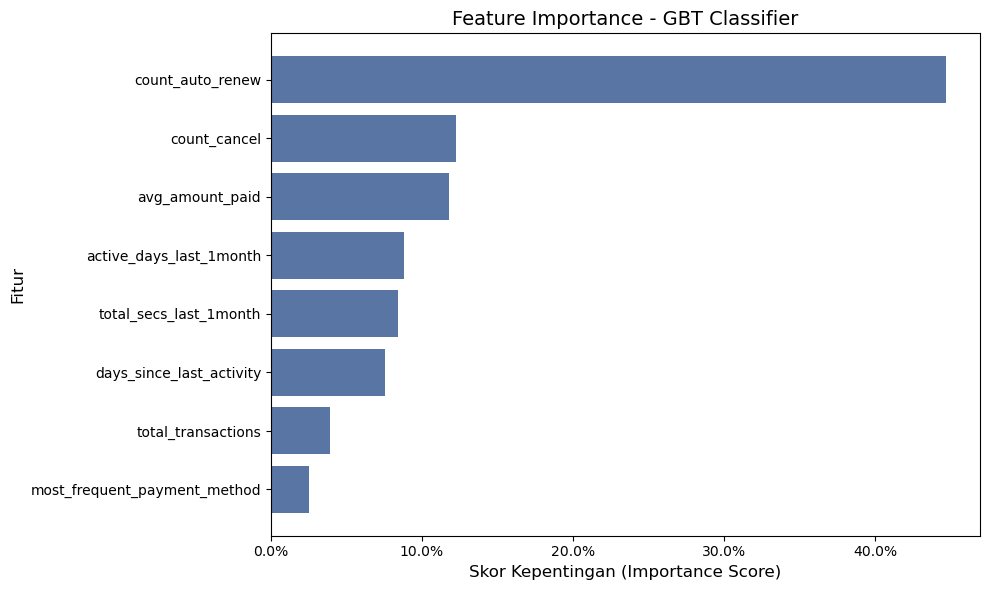

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Feature_Name': [
        'count_auto_renew',
        'count_cancel',
        'avg_amount_paid',
        'active_days_last_1month',
        'total_secs_last_1month',
        'days_since_last_activity',
        'total_transactions',
        'most_frequent_payment_method',
    ],
    'Importance_Score': [
        0.447133,
        0.122822,
        0.117640,
        0.088233,
        0.084407,
        0.075277,
        0.039004,
        0.025483,
    ]
}

df_importance = pd.DataFrame(data)
# Membersihkan nama fitur
# Hapus prefix 'numerical_features_'
df_importance = df_importance.sort_values(by='Importance_Score', ascending=True)
# Buat plot
plt.figure(figsize=(10, 6))
plt.barh(
    df_importance['Feature_Name'], 
    df_importance['Importance_Score'], 
    color='#5975A4'
)

# Label dan Judul
plt.xlabel('Skor Kepentingan (Importance Score)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.title('Feature Importance - GBT Classifier', fontsize=14)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

plt.tight_layout()


### Cross Validation

In [12]:
# --- 8. TRAINING GBT DENGAN CROSS-VALIDATION (CV) ---

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print("\n--- Melatih GBT dengan Cross-Validation & Tuning ---")

# 1. Tentukan GBT Estimator dan Pipeline
gbt_cv = GBTClassifier(labelCol=label_col, featuresCol="features", seed=42)
# Gunakan pipeline yang sama, hanya mengganti estimator GBT
pipeline_gbt_cv = Pipeline(stages=stages + [gbt_cv])

# 2. Tentukan Param Grid (Kombinasi Hyperparameter yang akan diuji)
# ini mencoba 4 kombinasi (2 maxDepth x 2 maxIter)
paramGrid = (ParamGridBuilder()
    .addGrid(gbt_cv.maxDepth, [5, 10])    # Kedalaman pohon
    .addGrid(gbt_cv.maxIter, [20, 50])     # Jumlah pohon/iterasi
    .build())

# 3. Tentukan Evaluator
evaluator = BinaryClassificationEvaluator(
    labelCol=label_col, 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC" # Metrik utama untuk memilih model terbaik
)

# 4. Tentukan CrossValidator
# numFolds=5 berarti data training dibagi menjadi 5 bagian
crossval = CrossValidator(estimator=pipeline_gbt_cv,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5, 
                          seed=42,
                          collectSubModels=False)

# 5. Latih Model (Ini akan melatih model 5 * 4 = 20 kali)
cvModel_gbt = crossval.fit(train_data_balanced)

best_gbt_model = cvModel_gbt.bestModel

preds_gbt_cv = best_gbt_model.transform(test_data)

roc_area_cv = evaluator.evaluate(preds_gbt_cv)
print(f"\nArea Under ROC (Model GBT Terbaik CV) pada data testing: {roc_area_cv:.4f}")
evaluate_model_detailed(preds_gbt_cv, "GBT Classifier (Best CV Model)")


--- Melatih GBT dengan Cross-Validation & Tuning ---

Area Under ROC (Model GBT Terbaik CV) pada data testing: 0.9790

DETAIL EVALUASI: GBT Classifier (Best CV Model)
Total Data Test: 216501
Accuracy       : 95.72%

[ Confusion Matrix ]
      	 Pred 0 	 Pred 1
Aktual 0: 192030		 4595
Aktual 1: 4673		 15203

--- Metrik per Kelas ---
KELAS           | PRECISION  | RECALL     | F1-SCORE  
-------------------------------------------------------
0 (Not Churn)   | 97.62%     | 97.66%     | 97.64%
1 (Churn)       | 76.79%     | 76.49%     | 76.64%
-------------------------------------------------------


In [13]:
best_gbt_estimator = best_gbt_model .stages[-1]

max_depth_terbaik = best_gbt_estimator._paramMap.get(best_gbt_estimator.maxDepth)
max_iter_terbaik = best_gbt_estimator._paramMap.get(best_gbt_estimator.maxIter)

print(f"Max Depth Terbaik: {max_depth_terbaik}")
print(f"Max Iterasi Terbaik: {max_iter_terbaik}")

Max Depth Terbaik: 10
Max Iterasi Terbaik: 50
